# Teams : PowerRangers

*Team members : Nicolas CORNU LAPORTE, Alix GALANT, Athenais MENDY*

# Water Potability Prediction

## Problem Definition
Access to safe drinking water is a fundamental human right and a critical factor for public health.
The objective of this project is to build a machine learning model capable of predicting whether a
water sample is safe for human consumption (**Potability = 1**) or not (**Potability = 0**).

This is a Binary Classification problem. We will use a dataset containing 9 water quality metrics:
- pH, Hardness, Solids (Total Dissolved Solids - TDS), Chloramines, Sulfate, Conductivity,
  Organic Carbon, Trihalomethanes, and Turbidity.



In [25]:

# general
import os
# import datas
import kagglehub
# data manipulation
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
# machine learning librairies
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
# save results
import joblib


# About Dataset

The dataset water_potability.csv contains data regarding 3276 bodies of water, compiling information about 10 different criteria for each.

The 10 criteria are the following:

### 1. pH value:
PH is an important parameter in evaluating the acid–base balance of water. It is also the indicator of acidic or alkaline condition of water status. WHO has recommended maximum permissible limit of pH from 6.5 to 8.5. The current investigation ranges were 6.52–6.83 which are in the range of WHO standards.

### 2. Hardness:
Hardness is mainly caused by calcium and magnesium salts. These salts are dissolved from geologic deposits through which water travels. The length of time water is in contact with hardness producing material helps determine how much hardness there is in raw water. Hardness was originally defined as the capacity of water to precipitate soap caused by Calcium and Magnesium.

### 3. Solids (Total dissolved solids - TDS):
Water has the ability to dissolve a wide range of inorganic and some organic minerals or salts such as potassium, calcium, sodium, bicarbonates, chlorides, magnesium, sulfates etc. These minerals produced un-wanted taste and diluted color in appearance of water. This is the important parameter for the use of water. The water with high TDS value indicates that water is highly mineralized. Desirable limit for TDS is 500 mg/l and maximum limit is 1000 mg/l which prescribed for drinking purpose.

### 4. Chloramines:
Chlorine and chloramine are the major disinfectants used in public water systems. Chloramines are most commonly formed when ammonia is added to chlorine to treat drinking water. Chlorine levels up to 4 milligrams per liter (mg/L or 4 parts per million (ppm)) are considered safe in drinking water.

### 5. Sulfate:
Sulfates are naturally occurring substances that are found in minerals, soil, and rocks. They are present in ambient air, groundwater, plants, and food. The principal commercial use of sulfate is in the chemical industry. Sulfate concentration in seawater is about 2,700 milligrams per liter (mg/L). It ranges from 3 to 30 mg/L in most freshwater supplies, although much higher concentrations (1000 mg/L) are found in some geographic locations.

### 6. Conductivity:
Pure water is not a good conductor of electric current rather’s a good insulator. Increase in ions concentration enhances the electrical conductivity of water. Generally, the amount of dissolved solids in water determines the electrical conductivity. Electrical conductivity (EC) actually measures the ionic process of a solution that enables it to transmit current. According to WHO standards, EC value should not exceeded 400 μS/cm.

### 7. Organic_carbon:
Total Organic Carbon (TOC) in source waters comes from decaying natural organic matter (NOM) as well as synthetic sources. TOC is a measure of the total amount of carbon in organic compounds in pure water. According to US EPA < 2 mg/L as TOC in treated / drinking water, and < 4 mg/Lit in source water which is use for treatment.

### 8. Trihalomethanes:
THMs are chemicals which may be found in water treated with chlorine. The concentration of THMs in drinking water varies according to the level of organic material in the water, the amount of chlorine required to treat the water, and the temperature of the water that is being treated. THM levels up to 80 ppm is considered safe in drinking water.

### 9. Turbidity:
The turbidity of water depends on the quantity of solid matter present in the suspended state. It is a measure of light emitting properties of water and the test is used to indicate the quality of waste discharge with respect to colloidal matter. The mean turbidity value obtained for Wondo Genet Campus (0.98 NTU) is lower than the WHO recommended value of 5.00 NTU.

### 10. Potability:
Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable.



# Loading the Dataset

In [26]:
# Download latest version
path = kagglehub.dataset_download("adityakadiwal/water-potability")

# Import datasets / DataFrame
df_train = pd.read_csv(path + "/water_potability.csv")

df_train.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [27]:
print("Full dataset shape is {}".format(df_train.shape))

Full dataset shape is (3276, 10)


# Basic exploration of the Dataset



In [28]:
df_train.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [29]:
df_train.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [30]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [31]:
df_train.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

# Visualization

### Water Potability Distribution

This pie chart shows the proportion of potable vs. non-potable water samples. A larger percentage of samples are non-potable (0) compared to potable (1).

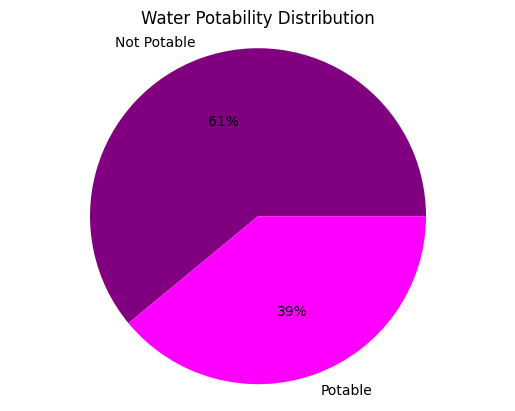

In [32]:
potability_counts = df_train['Potability'].value_counts().sort_index()

labels = ['Not Potable', 'Potable']
colors = ['Purple', 'Fuchsia']

plt.pie(potability_counts, labels=labels, colors=colors, autopct='%.0f%%')
plt.title('Water Potability Distribution')
plt.axis('equal')

plt.show()

In [33]:
#0 for Not potable, 1 for potable
print(potability_counts)

Potability
0    1998
1    1278
Name: count, dtype: int64


In [34]:
df_train[df_train['Potability']==0][['ph', 'Sulfate', 'Trihalomethanes']].median()

ph                   7.035456
Sulfate            333.389426
Trihalomethanes     66.542198
dtype: float64

In [35]:
df_train[df_train['Potability']==1][['ph', 'Sulfate', 'Trihalomethanes']].median()

ph                   7.036752
Sulfate            331.838167
Trihalomethanes     66.678214
dtype: float64

### Distribution of Individual Water Quality Parameters

These histograms show the frequency distribution of each water quality parameter across the dataset. They help in understanding the tendency and shape of the data for each feature.

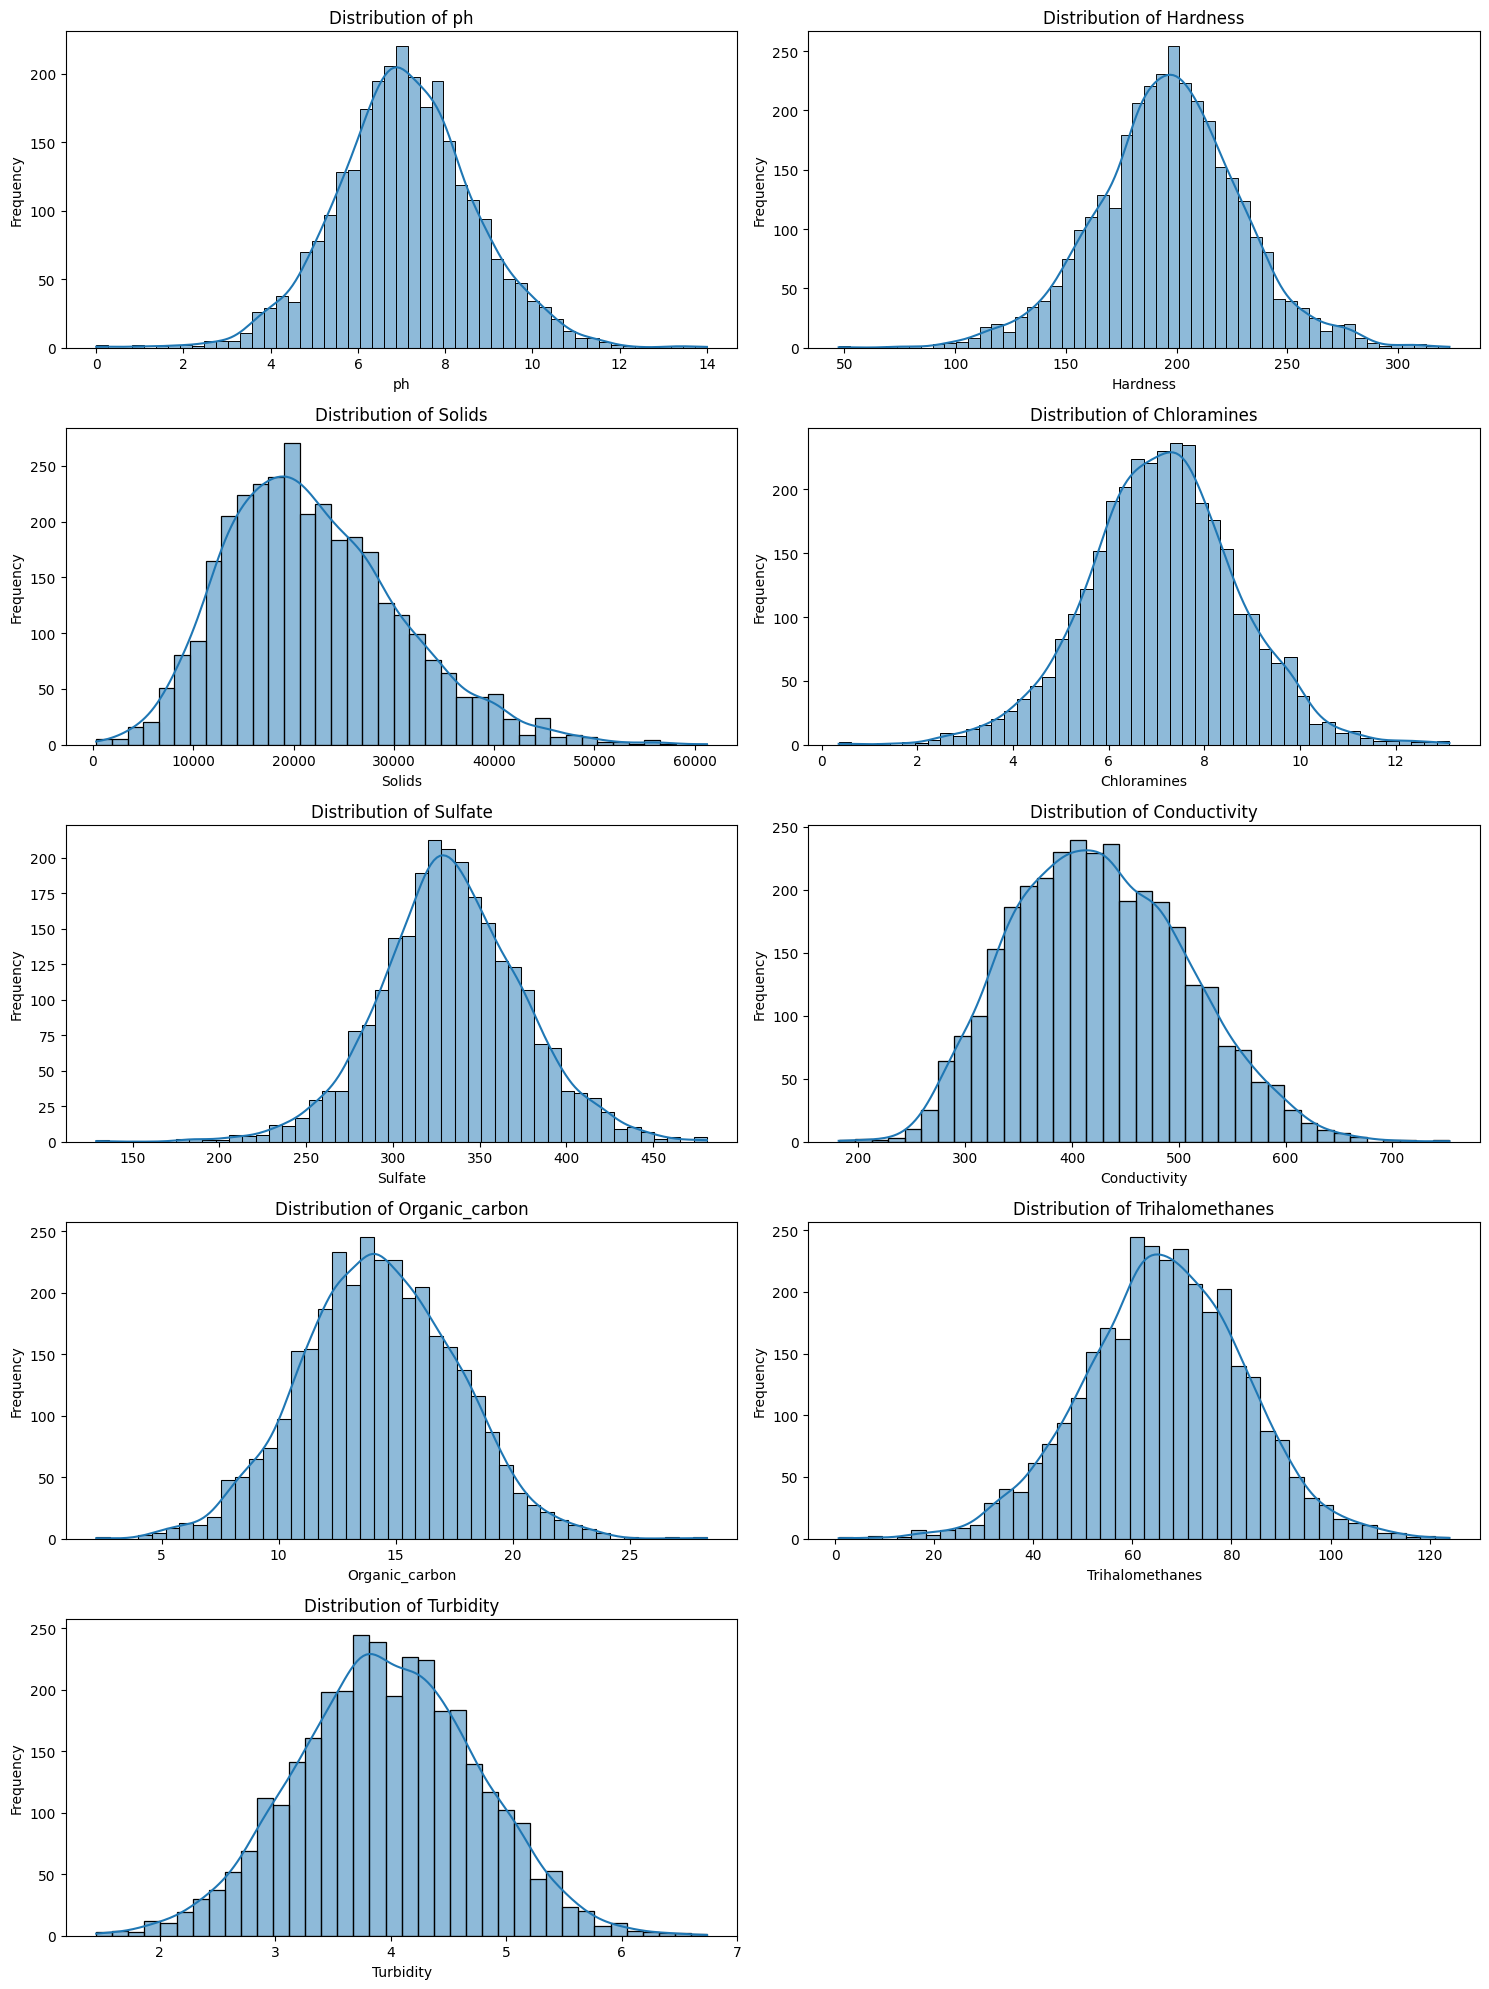

In [36]:
num_cols = df_train.select_dtypes(include=np.number).columns.drop('Potability')

plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols):
    plt.subplot(5, 2, i + 1)
    sns.histplot(df_train[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Water Quality Parameter Distributions by Potability

These box plots visualize each parameter's distribution by potability (0: non-potable, 1: potable), highlighting differences that may indicate importance for water potability.

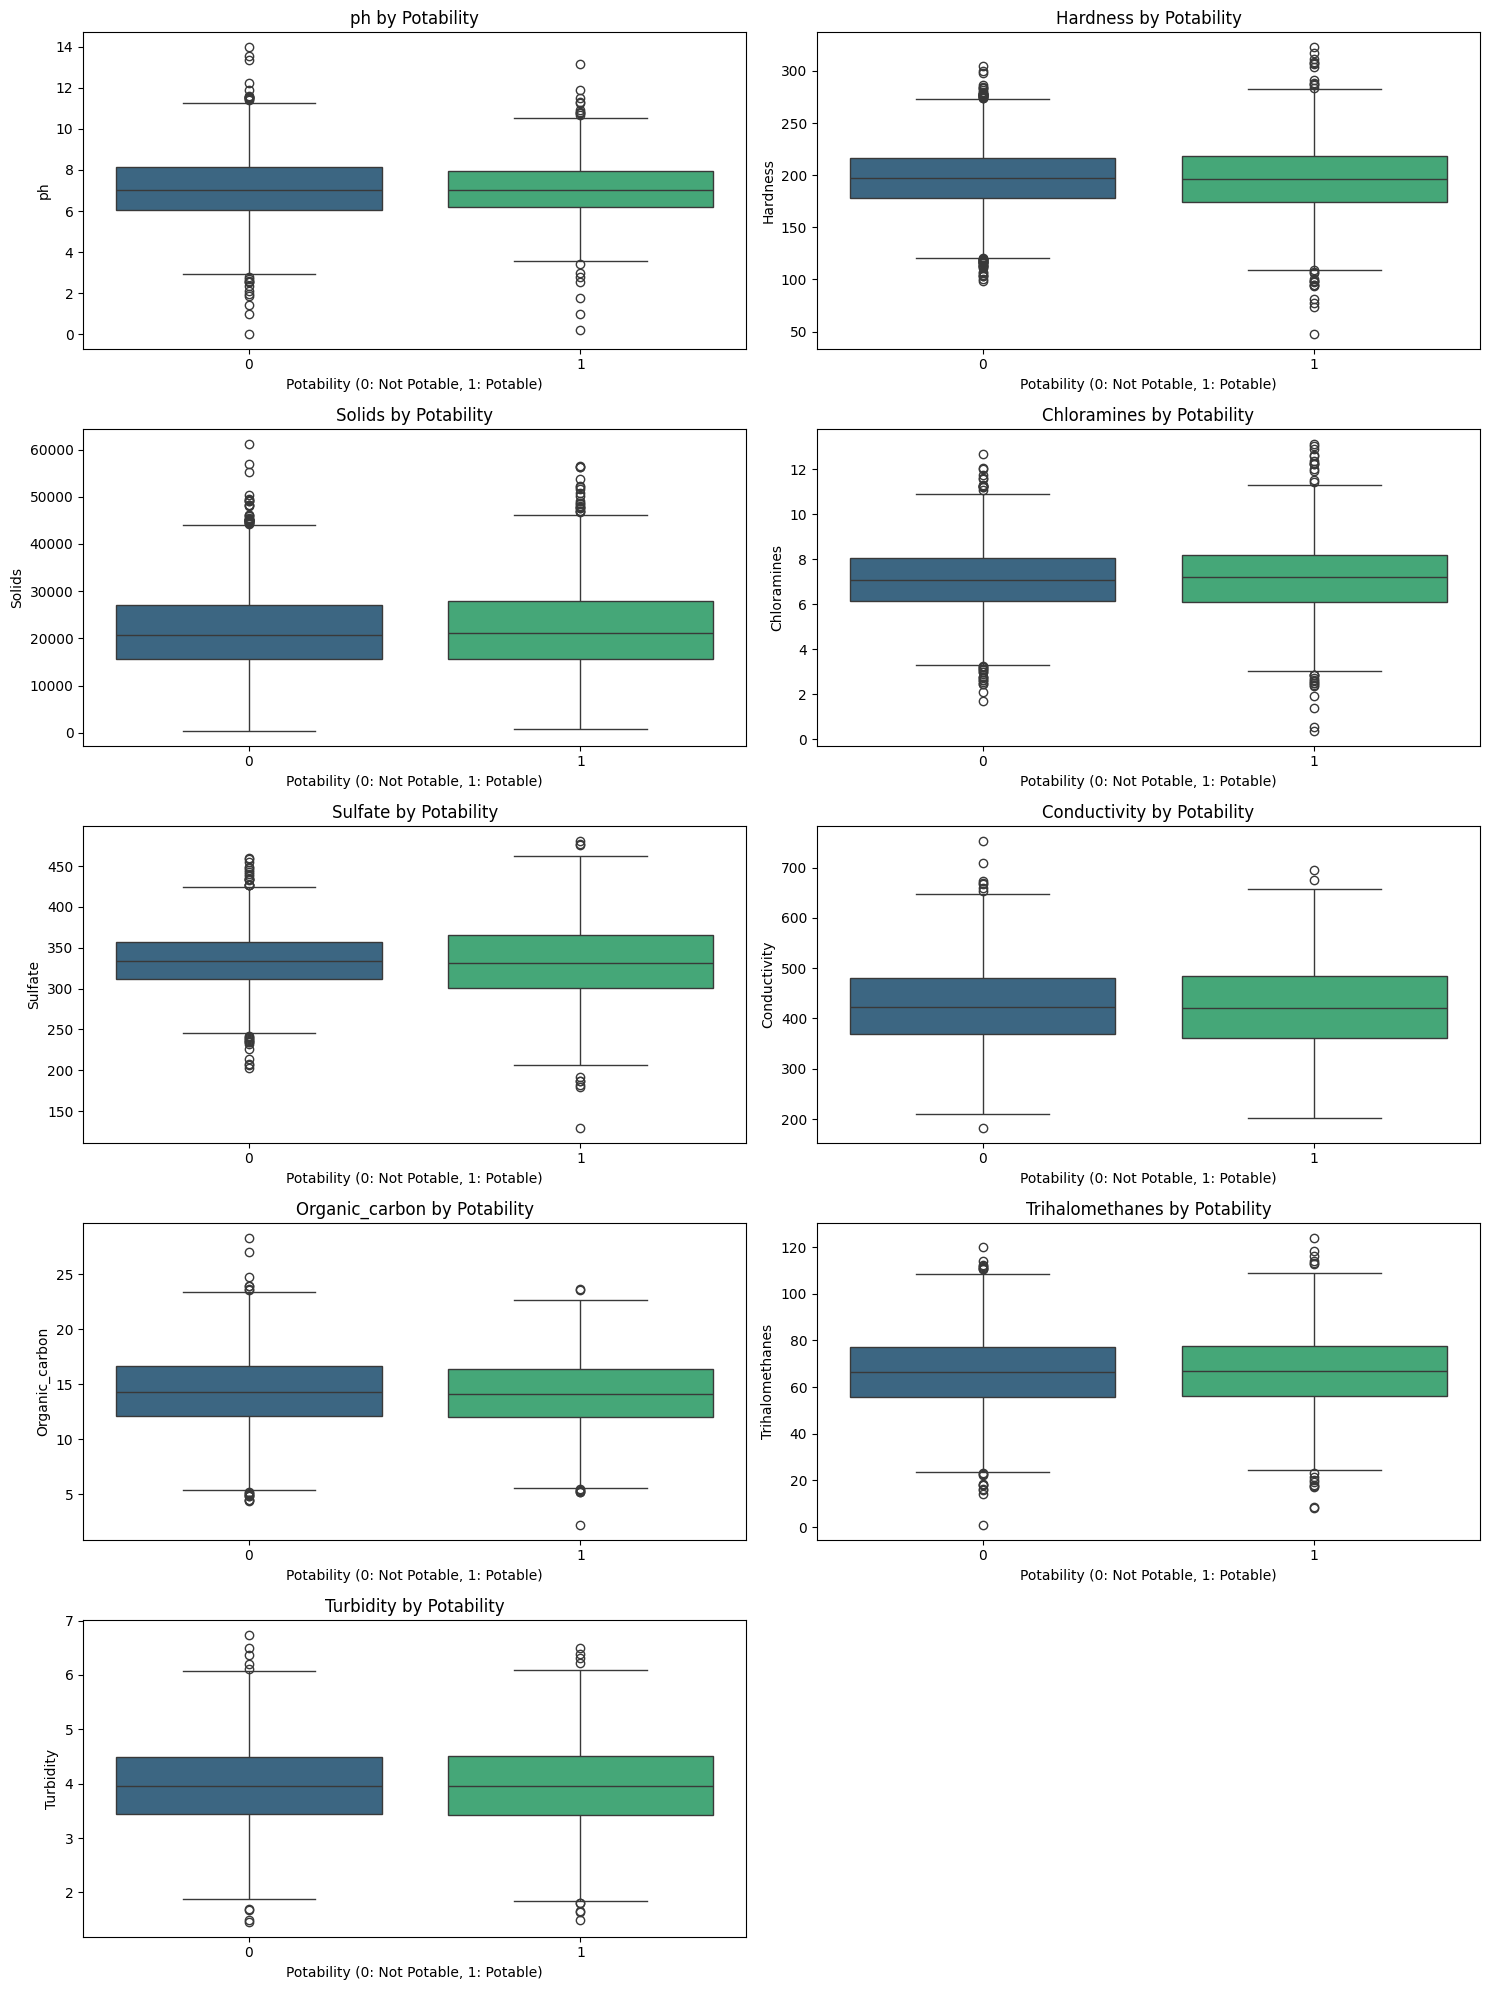

In [37]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols):
    plt.subplot(5, 2, i + 1)
    sns.boxplot(x='Potability', y=col, data=df_train, palette='viridis', hue='Potability', legend=False)
    plt.title(f'{col} by Potability')
    plt.xlabel('Potability (0: Not Potable, 1: Potable)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Water Quality Parameters Correlation Heatmap

This heatmap displays Pearson correlation coefficients between water quality parameters. Colors and values indicate the strength and direction of linear relationships; warm colors for positive, cool for negative.

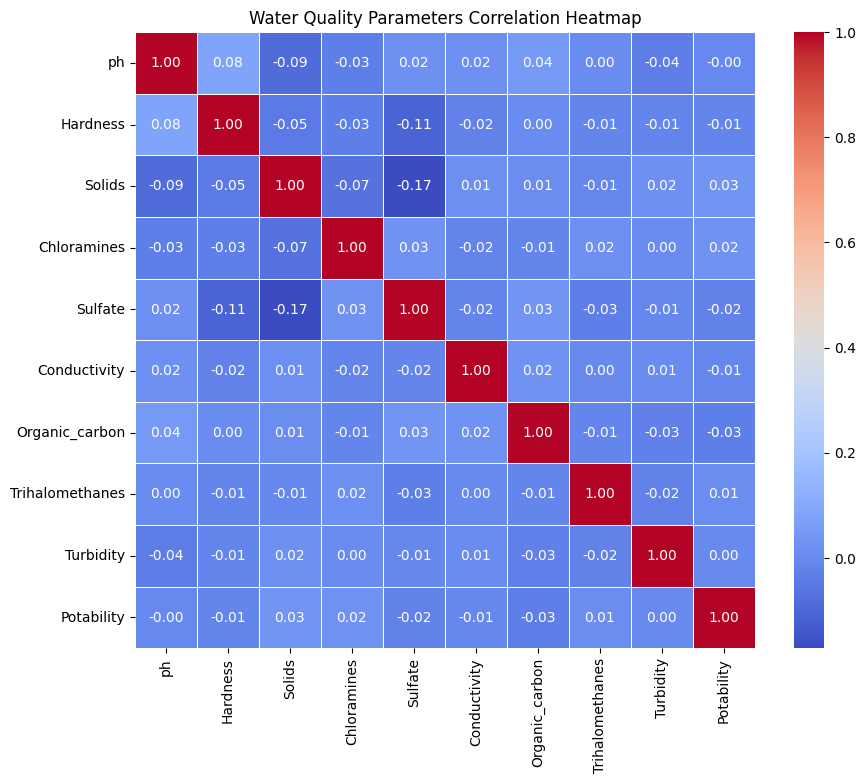

In [38]:
#Correletion between all the different parameters defining the dataset
plt.figure(figsize=(10, 8))
corr_matrix = df_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Water Quality Parameters Correlation Heatmap')
plt.show()

# Filling Missing Values

Missing values were imputed using the median of each respective column. This approach is robust to outliers and suitable for numerical data. Specifically, ph, Sulfate, and Trihalomethanes were filled with their medians from the training data.

### Distribution of Individual Water Quality Parameters

These histograms show the frequency distribution of each water quality parameter, helping to understand data spread and shape.

<Axes: >

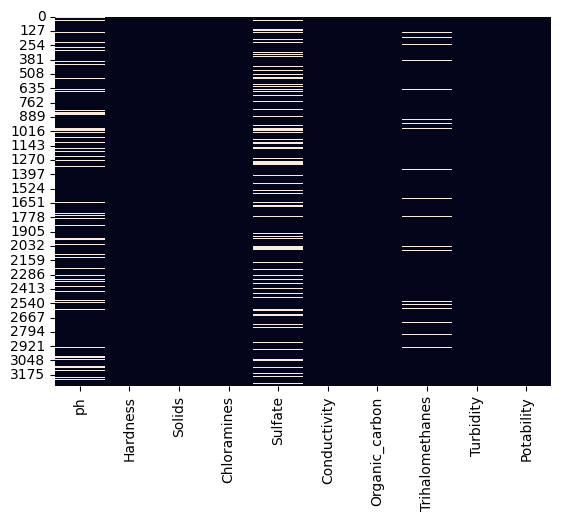

In [39]:
#Visualizing the null values
sns.heatmap(df_train.isnull(),cbar=False)

In [40]:
df_train = df_train.copy()
df_train.drop(columns=['Potability'])
df_train = df_train.fillna(df_train.median())

In [41]:
df_train.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

# Preprocessing

In [42]:

# Pre-processing
X = df_train.drop(columns=['Potability'])
y = df_train['Potability']

# Filling NaN values
X = X.fillna(X.median())

# Use 80% train, and 20% secret validation (with stratification to preserve class balance)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Select Models

In [43]:

# Models Dictionary
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=150, learning_rate=0.05, random_state=42, eval_metric='logloss')
}

# Dictionary to store scores
results = {}

# Training Models


 Training model : Random Forest
--- Report Assessment for model Random Forest ---
Global Accuracy : 0.6646
ROC-AUC score : 0.6579

Classification Report :
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.32      0.42       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



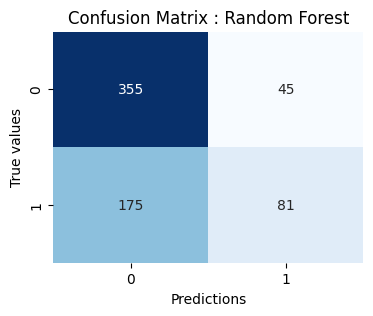


 Training model : Gradient Boosting
--- Report Assessment for model Gradient Boosting ---
Global Accuracy : 0.6601
ROC-AUC score : 0.6551

Classification Report :
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       400
           1       0.65      0.29      0.40       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.66      0.66      0.62       656



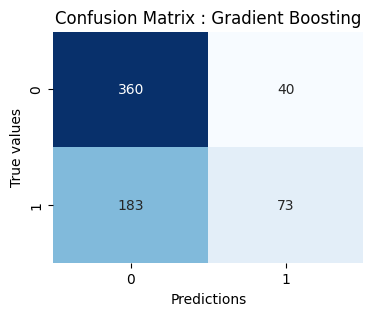


 Training model : XGBoost
--- Report Assessment for model XGBoost ---
Global Accuracy : 0.6799
ROC-AUC score : 0.6602

Classification Report :
              precision    recall  f1-score   support

           0       0.68      0.90      0.77       400
           1       0.68      0.34      0.46       256

    accuracy                           0.68       656
   macro avg       0.68      0.62      0.61       656
weighted avg       0.68      0.68      0.65       656



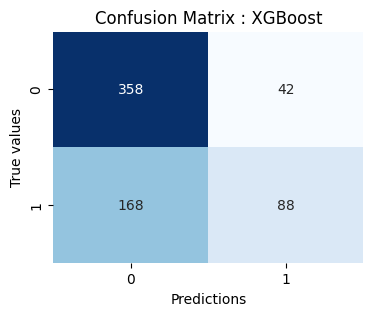

In [44]:
# Loop for Training and Evaluation
for name, model in models.items():
    print(f"\n Training model : {name}")

    # Training
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    # Compute Metrics
    acc = accuracy_score(y_val, preds)
    roc_auc = roc_auc_score(y_val, probs)

    results[name] = {"Accuracy": acc, "ROC-AUC": roc_auc}

    # Results Output
    print(f"--- Report Assessment for model {name} ---")
    print(f"Global Accuracy : {acc:.4f}")
    print(f"ROC-AUC score : {roc_auc:.4f}")
    print("\nClassification Report :")
    print(classification_report(y_val, preds))

    # Print Confusion Matrix
    cm = confusion_matrix(y_val, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix : {name}")
    plt.xlabel("Predictions")
    plt.ylabel("True values")
    plt.show()

# Final Comparison


=== FINAL RESULTS COMPARISON ===
                   Accuracy   ROC-AUC
Random Forest      0.664634  0.657930
Gradient Boosting  0.660061  0.655078
XGBoost            0.679878  0.660215


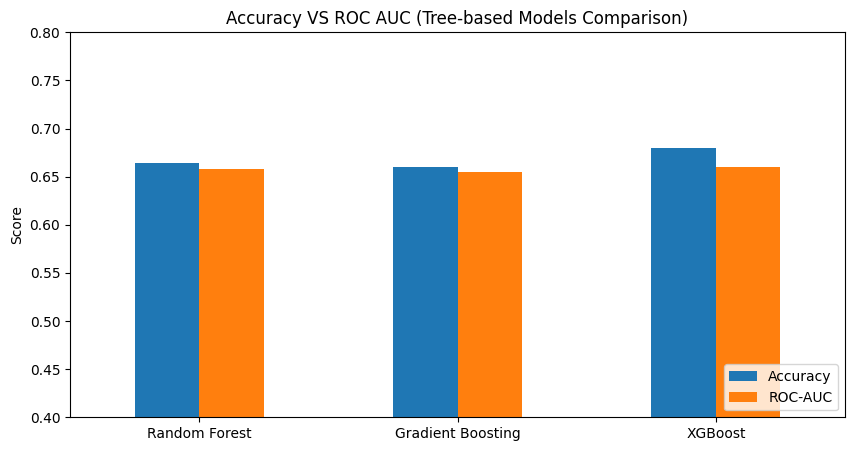

In [45]:
# FINAL COMPARISON
df_results = pd.DataFrame(results).T
print("\n=== FINAL RESULTS COMPARISON ===")
print(df_results)

# Performance Comparison Chart
df_results.plot(kind='bar', figsize=(10, 5))
plt.title('Accuracy VS ROC AUC (Tree-based Models Comparison)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.4, 0.8)
plt.legend(loc='lower right')
plt.show()



# Save Models as .pkl files

In [46]:
# Save models as .pkl files
for name, model in models.items():
    filename = name.replace(" ", "_").lower() + ".pkl"
    filepath = os.path.join("web/model", filename)

    joblib.dump(model, filepath)
    print(f"Saving Models : {filepath}")

Saving Models : web/model\random_forest.pkl
Saving Models : web/model\gradient_boosting.pkl
Saving Models : web/model\xgboost.pkl
